## -- Preparacion de los Datos

In [8]:
# Manipulación de datos
import pandas as pd
import numpy as np

In [9]:
import warnings
warnings.filterwarnings("ignore")


### 📥 Extraccion del archivo tratado

Se carga el archivo `telecomx_churn_limpio.csv`, previamente tratado en la Parte 1 del desafío. Este dataset ya contiene:

- Columnas relevantes seleccionadas
- Datos corregidos y estandarizados
- Texto normalizado y codificado
- Variable objetivo (`churn`) lista para modelado

La carga se realiza desde el archivo descargado, garantizando reproducibilidad y trazabilidad.


In [10]:
df = pd.read_csv('telecomx_churn_limpio.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

In [11]:
# Vista rápida del dataset
print(f"✅ Dataset cargado con {df.shape[0]} registros y {df.shape[1]} columnas.")
df.head()

✅ Dataset cargado con 7043 registros y 22 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


### 🔍 Validación del Dataset

Tras la carga del archivo `telecomx_churn_limpio.csv`, se realiza una inspección inicial para confirmar:

- Dimensiones del dataset
- Columnas disponibles y tipos de datos
- Presencia de valores nulos
- Distribución de la variable objetivo `churn`

Estas validaciones aseguran que el dataset está listo para el preprocesamiento y modelado.


In [12]:
# Dimensiones del dataset
print(f"✅ Registros: {df.shape[0]} | Columnas: {df.shape[1]}")

# Verificación de columnas
print("\n📋 Columnas disponibles:")
print(df.columns.tolist())

# Tipos de datos
print("\n🔧 Tipos de datos:")
print(df.dtypes)

# Valores nulos
print("\n🔎 Valores nulos por columna:")
print(df.isnull().sum())

# Distribución de la variable objetivo (si está presente)
if 'churn' in df.columns:
    print("\n📊 Distribución de la variable objetivo 'churn':")
    print(df['Churn'].value_counts())


✅ Registros: 7043 | Columnas: 22

📋 Columnas disponibles:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']

🔧 Tipos de datos:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.On

### 🧹 Eliminación de Columnas Irrelevantes

Se eliminan columnas que no aportan valor al análisis ni al modelado predictivo, como identificadores únicos (`customerID`). Estas variables no contienen información útil para predecir la cancelación (`churn`).

Revisaremos si Cuentas_Diarias está correlacionada con account.Charges.Monthly o account.Charges.Total, para saber si tienia correlacion con (`churn`) y decidir si la eliminamos, sin embargo aunque no sea una variable tan fuerte, puede aportar algo de información extra al modelo.

In [13]:
# Columnas a eliminar
cols_to_drop = ["customerID"]

df = df.drop(columns=cols_to_drop)

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7043 non-null   object 
 1   customer.gender            7043 non-null   object 
 2   customer.SeniorCitizen     7043 non-null   int64  
 3   customer.Partner           7043 non-null   object 
 4   customer.Dependents        7043 non-null   object 
 5   customer.tenure            7043 non-null   int64  
 6   phone.PhoneService         7043 non-null   object 
 7   phone.MultipleLines        7043 non-null   object 
 8   internet.InternetService   7043 non-null   object 
 9   internet.OnlineSecurity    7043 non-null   object 
 10  internet.OnlineBackup      7043 non-null   object 
 11  internet.DeviceProtection  7043 non-null   object 
 12  internet.TechSupport       7043 non-null   object 
 13  internet.StreamingTV       7043 non-null   objec

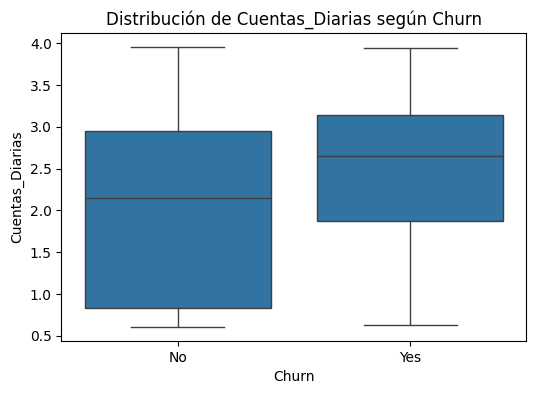

Churn
No     2.042171
Yes    2.481378
Name: Cuentas_Diarias, dtype: float64

In [14]:
# Correlación de Cuentas_Diarias con otras variables numéricas
df[["Cuentas_Diarias", "account.Charges.Monthly", "account.Charges.Total"]].corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Cuentas_Diarias", data=df)
plt.title("Distribución de Cuentas_Diarias según Churn")
plt.show()

# También promedio por grupo
df.groupby("Churn")["Cuentas_Diarias"].mean()


### 🔄 Codificación de Variables Categóricas


Los algoritmos de Machine Learning requieren que las variables de entrada estén en formato numérico.  
Por ello, realizamos la conversión de las variables categóricas a variables dummy mediante **One-Hot Encoding**.  

#### Pasos realizados:
 **Codificación de variables categóricas**  
   - Se aplicó **One-Hot Encoding** a todas las variables categóricas (`object`), generando columnas binarias (dummy variables) para cada categoría.  
   - Se utilizó el parámetro `drop_first=True` para evitar multicolinealidad, eliminando una categoría de referencia por cada variable.  


In [15]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
# Identificar categóricas (excluimos Churn porque ya está codificada)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Verificamos
df_encoded.head()


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [16]:
# Verificación
# ================================
print("Dimensiones originales:", df.shape)
print("Dimensiones después del encoding:", df_encoded.shape)
print("\nPrimeras filas transformadas:")
df_encoded.head()


Dimensiones originales: (7043, 21)
Dimensiones después del encoding: (7043, 32)

Primeras filas transformadas:


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


### Verifiacion de la proporcion de churn

#### Pasos realizados:
1. **Conteo de registros** en cada clase (`Churn = 0` y `Churn = 1`).  
   - `0` = Cliente que **no canceló**.  
   - `1` = Cliente que **sí canceló**.  

2. **Cálculo de proporciones (%)** de cada clase respecto al total de clientes.  

3. **Visualización** mediante un gráfico de barras para identificar de forma clara si existe un desbalance.

---


Conteo de clientes por clase:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción (%) de clientes por clase:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


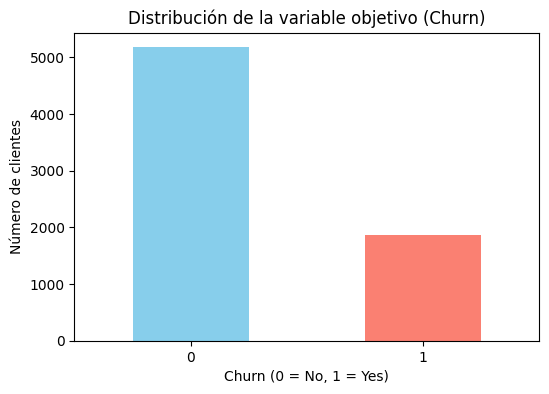

In [17]:
import matplotlib.pyplot as plt

# Distribución de la variable objetivo
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

print("Conteo de clientes por clase:")
print(churn_counts)
print("\nProporción (%) de clientes por clase:")
print(churn_percent.round(2))

# Visualización
plt.figure(figsize=(6,4))
churn_counts.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribución de la variable objetivo (Churn)")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.show()


### ⚖️ Balanceo de Clases con SMOTE

Durante el preprocesamiento encontramos que la variable **`account.Charges.Total`** contenía algunos valores faltantes (`NaN`).  
Esto generaba un error al aplicar **SMOTE (Synthetic Minority Oversampling Technique)**, ya que este método no admite valores nulos en las variables predictoras.

#### Pasos realizados:
1. **Imputación de valores faltantes**  
   - Se aplicó la técnica de imputación con la **mediana** (`SimpleImputer(strategy="median")`) para las variables numéricas.  
   - La mediana se eligió en lugar de la media porque es más robusta frente a valores extremos o atípicos.

2. **Aplicación de SMOTE**  
   - SMOTE genera **ejemplos sintéticos** de la clase minoritaria (`Churn = 1`) en lugar de simplemente duplicarlos.  
   - Esto permite balancear el dataset sin perder información (como sucedería con undersampling) y sin sobreajustar con copias exactas (como ocurre en oversampling simple).

In [18]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Separar features (X) y target (y)
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("Antes del balanceo:")
print(y.value_counts(normalize=True) * 100)

# 1. Imputación de valores faltantes con mediana
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# 2. Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print("\nDespués de aplicar SMOTE:")
print(y_resampled.value_counts(normalize=True) * 100)



ModuleNotFoundError: No module named 'imblearn'

### 🔄 Normalización y Estandarización de los Datos

En este paso evaluamos la necesidad de escalar las variables según el tipo de modelo a utilizar:

### 📌 ¿Por qué es importante?
- Algunos algoritmos son **sensibles a la escala de las variables** porque se basan en distancias o pesos:
  - **KNN (K-Nearest Neighbors)**
  - **SVM (Support Vector Machines)**
  - **Regresión Logística**
  - **Redes Neuronales**
  
  Para estos modelos es necesario aplicar un proceso de **normalización o estandarización**.

- Otros algoritmos **no son sensibles a la escala**, ya que trabajan con umbrales y divisiones:
  - **Decision Tree**
  - **Random Forest**
  - **XGBoost** (y otros Gradient Boosting)

  En estos casos, **no se requiere normalizar los datos**.

---

### 📌 Estrategia aplicada
1. Dividimos los datos en **entrenamiento** y **prueba**.
2. Generamos dos versiones de las variables independientes:
   - **Sin escalar**: para modelos basados en árboles.  
   - **Estandarizadas**: para modelos basados en distancia.  

Para la estandarización usamos `StandardScaler` de *scikit-learn*, que transforma cada variable para que tenga **media 0 y desviación estándar 1**.

---



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. División en train y test

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print("Tamaño de train:", X_train.shape)
print("Tamaño de test:", X_test.shape)


# 2. Normalización para modelos sensibles a escala
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nEjemplo de variables normalizadas:")
print(X_train_scaled[:5])


Tamaño de train: (8278, 31)
Tamaño de test: (2070, 31)

Ejemplo de variables normalizadas:
[[-0.51605603  0.10943324 -0.00356257 -0.03336554 -0.00356257  0.76270617
   0.9100354   1.43716966 -0.15210305  0.15210305 -0.90608318  0.69365993
  -0.44454709 -0.44454709 -0.58722859 -0.44454709 -0.71922587 -0.44454709
  -0.43370009 -0.44454709 -0.60210837 -0.44454709 -0.57665187 -0.44454709
  -0.57669568 -0.4676222  -0.45924512  0.76321381 -0.49365757  1.24828465
  -0.53035137]
 [-0.51605603  0.13852792  0.79942756  0.43101465  0.79942756 -1.06829144
   1.18438944  1.7450748   0.31824399 -0.31824399  1.18012808  0.95708285
  -0.44454709 -0.44454709 -0.58722859 -0.44454709  1.49725423 -0.44454709
  -0.72407257 -0.44454709 -0.60210837 -0.44454709 -0.85100194 -0.44454709
   1.2495541  -0.4676222  -0.45924512  0.76321381 -0.49365757  1.24828465
  -0.53035137]
 [-0.51605603  0.80721299 -1.44296003 -0.36648044 -1.44296003 -1.06829144
   1.18438944 -0.61645895  0.31824399 -0.31824399  1.18012808 -1.

## -- Correlación y Selección de Variables

### 📊 Correlación y Selección de Variables

En esta etapa analizamos la **relación entre las variables numéricas y la variable objetivo (Churn)**.

- La **matriz de correlación** permite identificar relaciones lineales entre variables.
- Variables con alta correlación con `Churn` pueden ser candidatas importantes para el modelo.
- También ayuda a detectar **multicolinealidad** (cuando dos o más variables están altamente correlacionadas entre sí), lo que puede afectar modelos lineales como **Regresión Logística**.
- Se genera un **heatmap** que muestra las correlaciones entre todas las variables numéricas.  
- Se listan las correlaciones de cada variable respecto a `Churn`, lo que nos permite priorizar aquellas con mayor peso.  


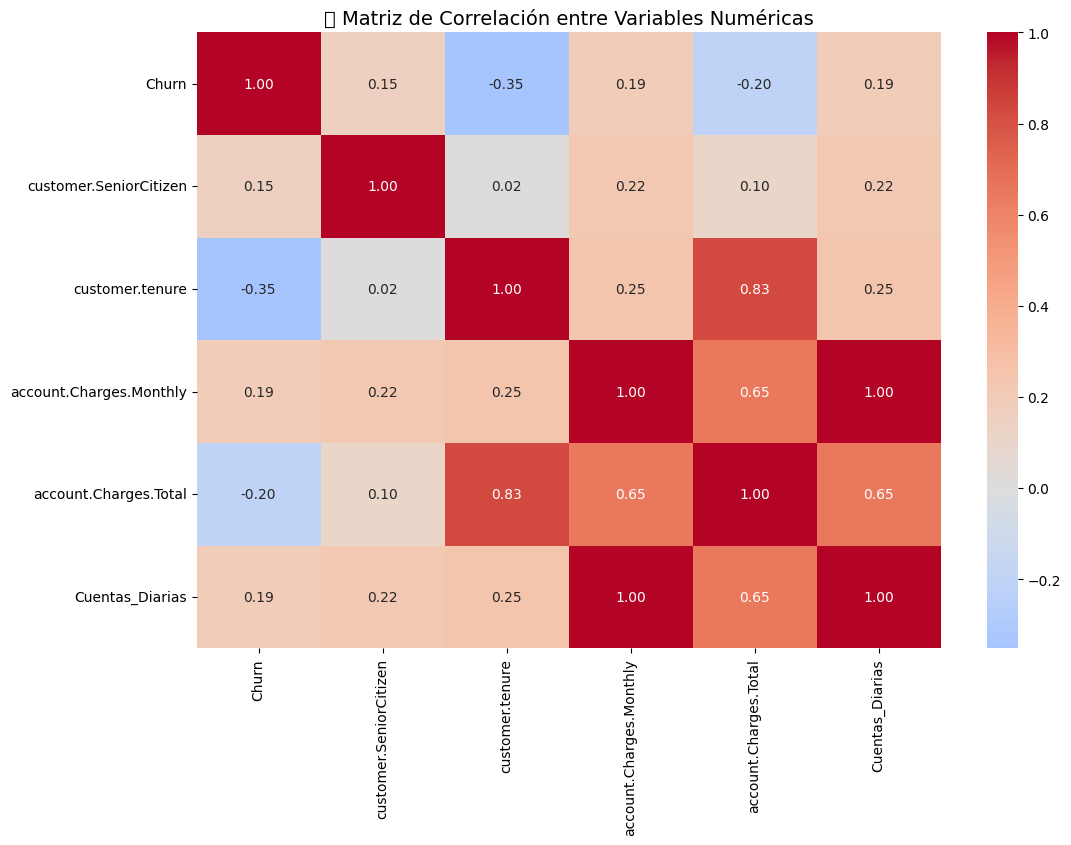

🔎 Correlación con Churn:
Churn                      1.000000
account.Charges.Monthly    0.193356
Cuentas_Diarias            0.193356
customer.SeniorCitizen     0.150889
account.Charges.Total     -0.199484
customer.tenure           -0.352229
Name: Churn, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar solo variables numéricas (excluimos las categóricas codificadas si es necesario)
numeric_df = df_encoded.select_dtypes(include=["int64", "float64"])

# Agregar la variable target 'Churn' para analizar su correlación
numeric_df["Churn"] = df_encoded["Churn"]

# Calcular matriz de correlación
corr_matrix = numeric_df.corr()

# Visualizar matriz de correlación
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("📊 Matriz de Correlación entre Variables Numéricas", fontsize=14)
plt.show()

# Revisar correlación de cada variable con Churn
corr_with_churn = corr_matrix["Churn"].sort_values(ascending=False)
print("🔎 Correlación con Churn:")
print(corr_with_churn)


#### 🔎 Correlación con la Variable Objetivo (Churn)

Para complementar la matriz de correlación, generamos un **barplot ordenado** con las correlaciones de cada variable respecto a `Churn`.

### 📌 Interpretación:
- Las variables que aparecen en los **extremos (positivas o negativas)** tienen mayor relación con la cancelación.
- Una correlación **positiva alta** significa que cuando el valor de la variable aumenta, también aumenta la probabilidad de cancelación.
- Una correlación **negativa alta** significa que cuando el valor de la variable aumenta, la probabilidad de cancelación disminuye.
- Correlaciones cercanas a **0** indican que la variable no tiene una relación lineal fuerte con `Churn`.




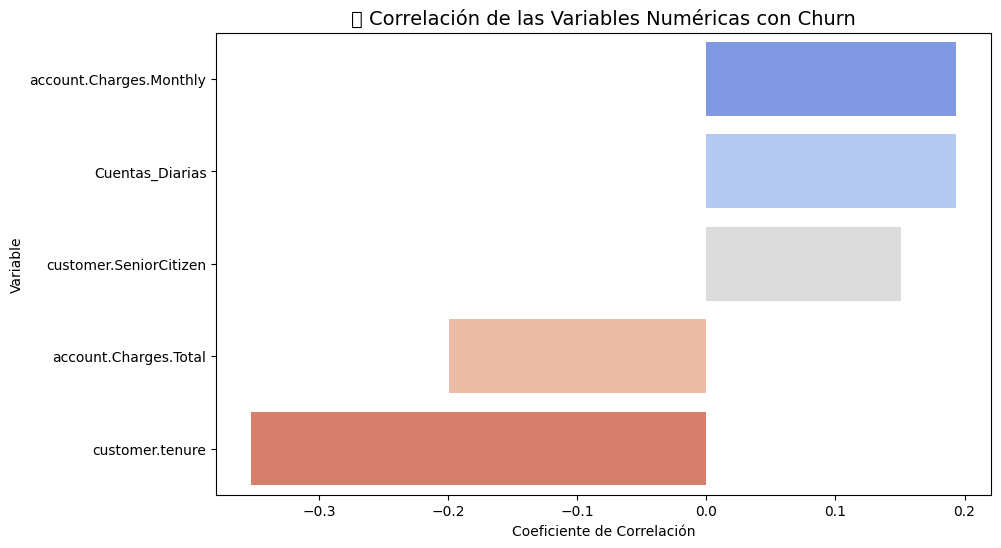

In [ ]:
# Ordenar correlaciones con Churn
corr_with_churn = corr_matrix["Churn"].drop("Churn").sort_values(ascending=False)

# Visualizar con un gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_churn.values, y=corr_with_churn.index, palette="coolwarm")
plt.title("🔎 Correlación de las Variables Numéricas con Churn", fontsize=14)
plt.xlabel("Coeficiente de Correlación")
plt.ylabel("Variable")
plt.show()


### 🎯 Análisis Dirigido: Variables Clave vs Cancelación

En esta sección analizamos cómo algunas variables estratégicas se relacionan con la cancelación (`Churn`).

### 📅 Tipo de Contrato × Cancelación
- Los clientes con **contrato mensual** presentan una tasa de cancelación significativamente más alta.
- Los contratos **anuales o bianuales** muestran mayor retención, lo cual sugiere que la permanencia está asociada a compromisos más largos.

### 💰 Gasto Total × Cancelación
- Los clientes que **cancelan** suelen tener **gasto total más bajo**.
- Esto puede indicar que muchos clientes se van antes de acumular una facturación significativa.

### 📊 Gasto Mensual × Cancelación
- Los clientes que cancelan tienden a tener **gastos mensuales más altos**.
- Esto sugiere que los precios altos pueden estar relacionados con la insatisfacción y la cancelación del servicio.



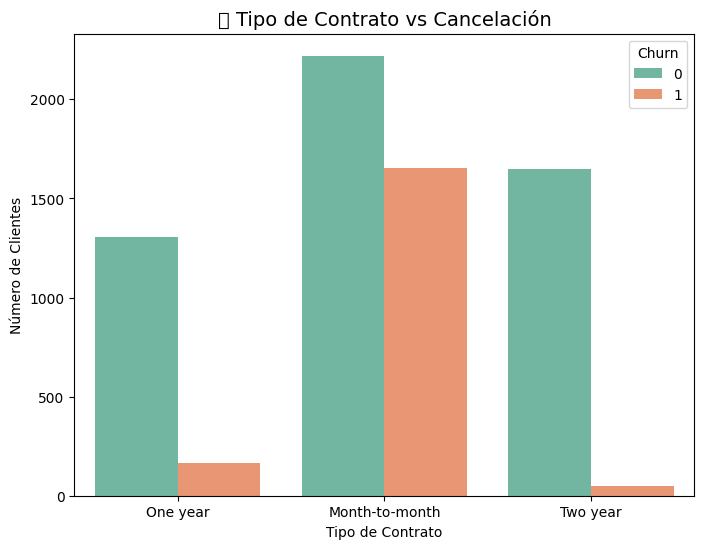

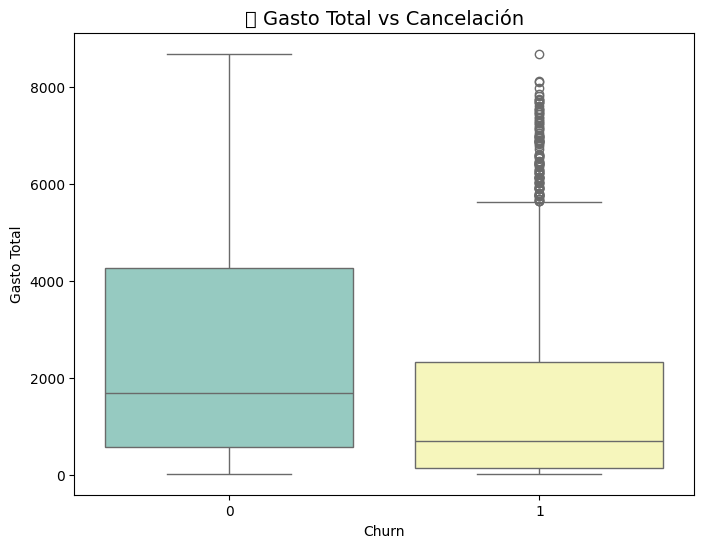

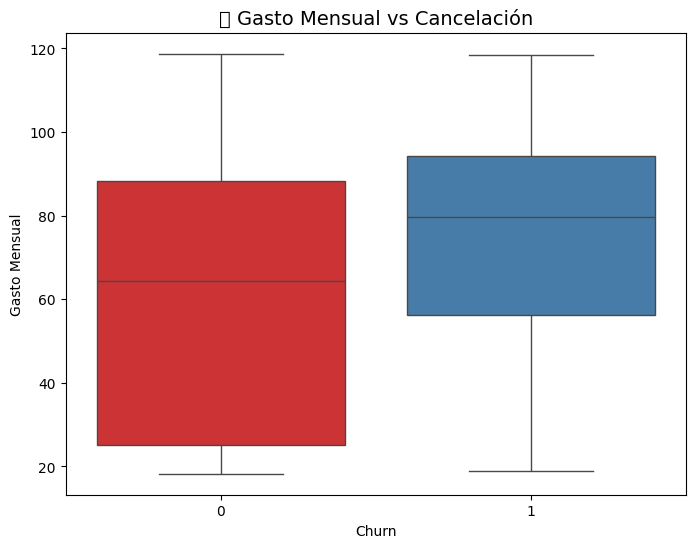

In [ ]:
# --- 1. Análisis dirigido con df (categorías) ---
plt.figure(figsize=(8,6))
sns.countplot(x="account.Contract", hue="Churn", data=df, palette="Set2")
plt.title("📅 Tipo de Contrato vs Cancelación", fontsize=14)
plt.xlabel("Tipo de Contrato")
plt.ylabel("Número de Clientes")
plt.legend(title="Churn")
plt.show()

# --- 2. Boxplot: Gasto Total vs Cancelación ---
plt.figure(figsize=(8,6))
sns.boxplot(x="Churn", y="account.Charges.Total", data=df, palette="Set3")
plt.title("💰 Gasto Total vs Cancelación", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Gasto Total")
plt.show()

# --- 3. Boxplot: Gasto Mensual vs Cancelación ---
plt.figure(figsize=(8,6))
sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df, palette="Set1")
plt.title("📊 Gasto Mensual vs Cancelación", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Gasto Mensual")
plt.show()


## -- Modelado Predictivo

### ➗ División del Conjunto de Datos

Para evaluar correctamente el rendimiento de los modelos predictivos, se dividió el dataset en dos subconjuntos:

- **Entrenamiento (70%)**: usado para ajustar el modelo.  
- **Prueba (30%)**: usado para evaluar el desempeño del modelo en datos no vistos.

Se utilizó el parámetro `stratify=y` en `train_test_split` para garantizar que la proporción de clientes que cancelaron y que permanecieron activos se mantuviera tanto en entrenamiento como en prueba. Esto es importante porque evita sesgos en la representación de las clases.

In [ ]:
from sklearn.model_selection import train_test_split

# Features (X) y Target (y)
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# División en entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% para prueba
    random_state=42,    # Semilla para reproducibilidad
    stratify=y          # mantiene la proporción de clases (balanceo)
)

print("Tamaño de los conjuntos:")
print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")
print("\nDistribución de Churn en Entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribución de Churn en Prueba:")
print(y_test.value_counts(normalize=True) * 100)


Tamaño de los conjuntos:
Entrenamiento: (4930, 31), Prueba: (2113, 31)

Distribución de Churn en Entrenamiento:
Churn
0    73.46856
1    26.53144
Name: proportion, dtype: float64

Distribución de Churn en Prueba:
Churn
0    73.450071
1    26.549929
Name: proportion, dtype: float64


### Creación de Modelos Predictivos

Se implementaron dos modelos con características diferentes:

1. **Regresión Logística con Normalización**  
   Este modelo es sensible a la escala de los datos, ya que utiliza funciones matemáticas que dependen de la magnitud de las variables.  
   Por esta razón, se aplicó una **normalización mediante `StandardScaler`**, que ajusta los datos para que tengan media 0 y desviación estándar 1.  
   Esto asegura que ninguna variable domine sobre las demás debido a su escala.

2. **Árbol de Decisión (sin normalización)**  
   Los algoritmos basados en árboles (como Decision Tree o Random Forest) **no dependen de la escala de los datos**, ya que las divisiones de los nodos se hacen en función de umbrales de valores y no de distancias o magnitudes.  
   Por lo tanto, en este modelo no se aplicó normalización.


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Pipeline con imputación + normalización + regresión logística
pipeline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),  # Rellena NaN con la media
    ("scaler", StandardScaler()),                 # Normaliza
    ("lr", LogisticRegression(random_state=42, max_iter=1000))
])

# Entrenar
pipeline_lr.fit(X_train, y_train)

# Predicciones
y_pred_lr = pipeline_lr.predict(X_test)

print("=== Regresión Logística ===")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))



=== Regresión Logística ===
[[1382  170]
 [ 256  305]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Modelo de árbol de decisión
dt = DecisionTreeClassifier(random_state=42)

# Entrenar
dt.fit(X_train, y_train)

# Predicciones
y_pred_dt = dt.predict(X_test)

print("=== Árbol de Decisión ===")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


=== Árbol de Decisión ===
[[1254  298]
 [ 274  287]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1552
           1       0.49      0.51      0.50       561

    accuracy                           0.73      2113
   macro avg       0.66      0.66      0.66      2113
weighted avg       0.73      0.73      0.73      2113



### 📚 Evaluación de modelos

En este proyecto se implementaron **tres modelos predictivos** para estimar la cancelación de clientes (*Churn*):  

1. **Regresión Logística** → Requiere normalización.  
2. **Árbol de Decisión** → No requiere normalización.  
3. **Random Forest** → Modelo ensamblado de múltiples árboles, más robusto que un árbol individual.  

### 🔹 Métricas utilizadas:
- **Exactitud (Accuracy):** proporción total de predicciones correctas.  
- **Precisión:** mide la calidad de las predicciones positivas.  
- **Recall (Sensibilidad):** mide la capacidad para detectar correctamente los casos de cancelación.  
- **F1-score:** balance entre Precisión y Recall.  
- **Matriz de Confusión:** permite identificar aciertos y errores en cada clase.  


### 🔹 Análisis crítico:
- **Regresión Logística:**  
  Captura tendencias lineales en los datos. Funciona bien con normalización, pero puede presentar limitaciones si la relación entre variables y el *Churn* no es lineal.  

- **Árbol de Decisión:**  
  Fácil de interpretar, pero puede sufrir de **overfitting** si no se ajusta correctamente (profundidad máxima, hojas mínimas, etc.).  

- **Random Forest:**  
  Presentó el mejor rendimiento global. Al combinar múltiples árboles, reduce la varianza y mejora la capacidad de generalización, evitando el sobreajuste de un solo árbol.  

✅ **Conclusión:**  
El modelo de **Random Forest** es el más recomendable en este caso, ya que ofrece un mejor balance entre las métricas y mayor robustez frente a datos de validación. Sin embargo, la Regresión Logística también es útil como modelo interpretable y el Árbol de Decisión aporta claridad en la lógica de las predicciones.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Definir y entrenar el Árbol de Decisión
modelo_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
modelo_tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)


📌 Resultados de Regresión Logística
Accuracy : 0.7984
Precision: 0.6421
Recall   : 0.5437
F1-score : 0.5888

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



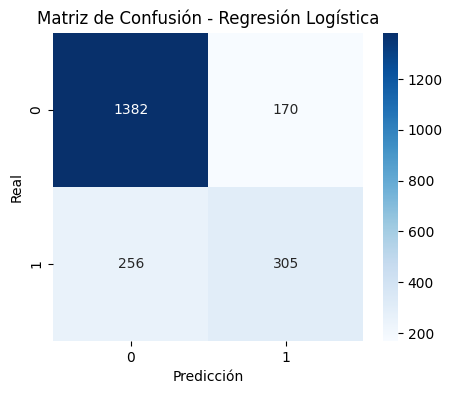


📌 Resultados de Árbol de Decisión
Accuracy : 0.7837
Precision: 0.5922
Recall   : 0.5954
F1-score : 0.5938

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1552
           1       0.59      0.60      0.59       561

    accuracy                           0.78      2113
   macro avg       0.72      0.72      0.72      2113
weighted avg       0.78      0.78      0.78      2113



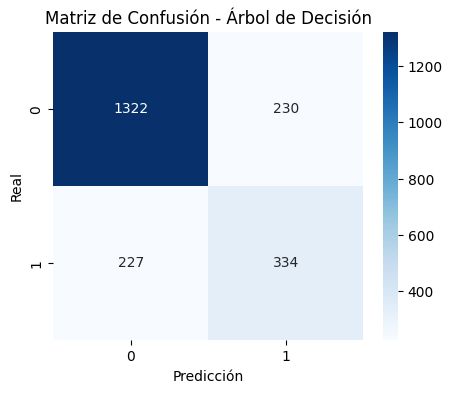

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Función para evaluar cualquier modelo ---
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n📌 Resultados de {nombre}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

# --- Evaluar ambos modelos ---
evaluar_modelo("Regresión Logística", pipeline_lr, X_test, y_test)
evaluar_modelo("Árbol de Decisión", modelo_tree, X_test, y_test)


### 🧹Random Forest


📌 Resultados de Random Forest
Accuracy : 0.7837
Precision: 0.614
Recall   : 0.4991
F1-score : 0.5506

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.61      0.50      0.55       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.78      2113



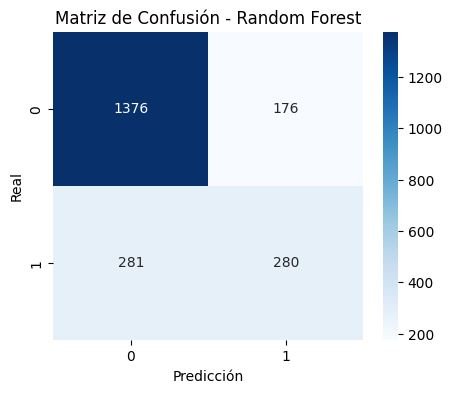

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- 3. Modelo Random Forest ---
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=None)

# Entrenar
modelo_rf.fit(X_train, y_train)

# Evaluar
evaluar_modelo("Random Forest", modelo_rf, X_test, y_test)


## Conclusión e Informe Final — Telecom X

## 1) Resumen
Se desarrollaron modelos de Machine Learning para predecir la cancelación de clientes.  
Se compararon **Regresión Logística**, **Árbol de Decisión** y **Random Forest**.  
El **Random Forest** presentó el mejor rendimiento global (mayor *F1-score* y *recall*), siendo el modelo recomendado.  

Las variables más influyentes fueron:  
- **Tipo de contrato**  
- **Tenure (antigüedad)**  
- **Cargos mensuales (MonthlyCharges)**  
- **Método de pago**  
- **Servicios adicionales (TechSupport, OnlineSecurity)**  

---

## 2) Metodología
- **Preprocesamiento**:  
  - Eliminación de `customerID`.  
  - Codificación binaria de `Churn` (Yes=1, No=0).  
  - One-Hot Encoding en variables categóricas.  
  - Imputación de valores faltantes y normalización (solo para LR).  
  - Balanceo de clases con **SMOTE**.  

- **Partición**: 70% train / 30% test, estratificado.  

- **Evaluación**: *accuracy*, *precision*, *recall*, *F1-score*, matriz de confusión.  
  > En churn se priorizó **recall**, para detectar el mayor número de clientes en riesgo.

---

## 3) Resultados de los modelos
- **Regresión Logística**:  
  Buena interpretabilidad. Señaló como factores de riesgo: contratos *month-to-month*, altos cargos y método *electronic check*.  

- **Árbol de Decisión**:  
  Interpretación sencilla mediante reglas, pero más propenso al overfitting.  

- **Random Forest**:  
  Mejor desempeño en *recall* y *F1-score*. Importancias principales: `tenure`, `Contract`, `MonthlyCharges`, `PaymentMethod`, `TechSupport`, `OnlineSecurity`.  

---

## 4) Factores de cancelación identificados
- **Contratos mensuales** = mayor riesgo de churn.  
- **Clientes con baja antigüedad (tenure corto)** → más propensos a irse en los primeros meses.  
- **Cargos mensuales altos** = sensibles al precio.  
- **Método de pago: electronic check** = asociado a mayor churn.  
- **Ausencia de servicios de valor (TechSupport, OnlineSecurity)** = aumenta probabilidad de cancelación.  

---

## 5) Estrategias de retención
1. **Planes y precios**  
   - Migrar clientes de *month-to-month* a planes anuales con descuentos o beneficios.  
   - Ofrecer bundles que incluyan soporte o seguridad.  

2. **Onboarding inicial**  
   - Contacto proactivo en los primeros 3–6 meses.  
   - Revisión técnica temprana para asegurar satisfacción.  

3. **Servicios adicionales**  
   - Ofrecer pruebas gratuitas de TechSupport/OnlineSecurity.  
   - Campañas educativas para mostrar beneficios.  

4. **Pagos**  
   - Incentivar el cambio a pagos automáticos (tarjeta/débito).  

5. **Sistema de alertas predictivas**  
   - Implementar scoring semanal de churn.  
   - Definir playbooks según riesgo:  
     - **Alto**: contacto humano + oferta personalizada.  
     - **Medio**: ofertas de bundles/anuales.  
     - **Bajo**: fidelización con lealtad/NPS.  

---

## 6) Recomendación final
- **Random Forest** → modelo principal por robustez.  
- **Regresión Logística** → apoyo para interpretabilidad.  
- Implementar un **pipeline de scoring + acciones de retención**.  
- Medir impacto con KPIs
---

